# Импорт библиотек

In [90]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt

# для загрузок логин пароль
import os
from dotenv import load_dotenv

# Настройка CometML
<img src='https://www.comet.com/site/wp-content/uploads/2022/05/comet-logo.svg' width=500px>

In [91]:
# !pip install comet_ml

In [92]:
from comet_ml import Experiment

In [93]:
# загрузка данных из ".env"
load_dotenv()
# Создайте эксперимент с помощью вашего API ключа
experiment = Experiment(
    api_key=os.getenv('api_key'),
    project_name=os.getenv('project_name'),
    workspace=os.getenv('workspace'),
)

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/glorit/medical-appointment/4784960d0219477fbed0fcdc158e7bd7
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     figures                  : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (142.58 KB)
COMET INFO:     installed packages       : 1
COMET INFO:     notebook                 : 1
COMET INFO:     source_code              : 1
COMET INFO: 
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exit

# Загрузка данных

In [94]:
df = pd.read_csv('../data/KaggleV2-May-2016.csv')

In [95]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# Визуализация

### Распределение числовых признаков

{'web': 'https://www.comet.com/api/image/download?imageId=3a66f87a8f794b6d9930401e811ae323&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=3a66f87a8f794b6d9930401e811ae323&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'imageId': '3a66f87a8f794b6d9930401e811ae323'}

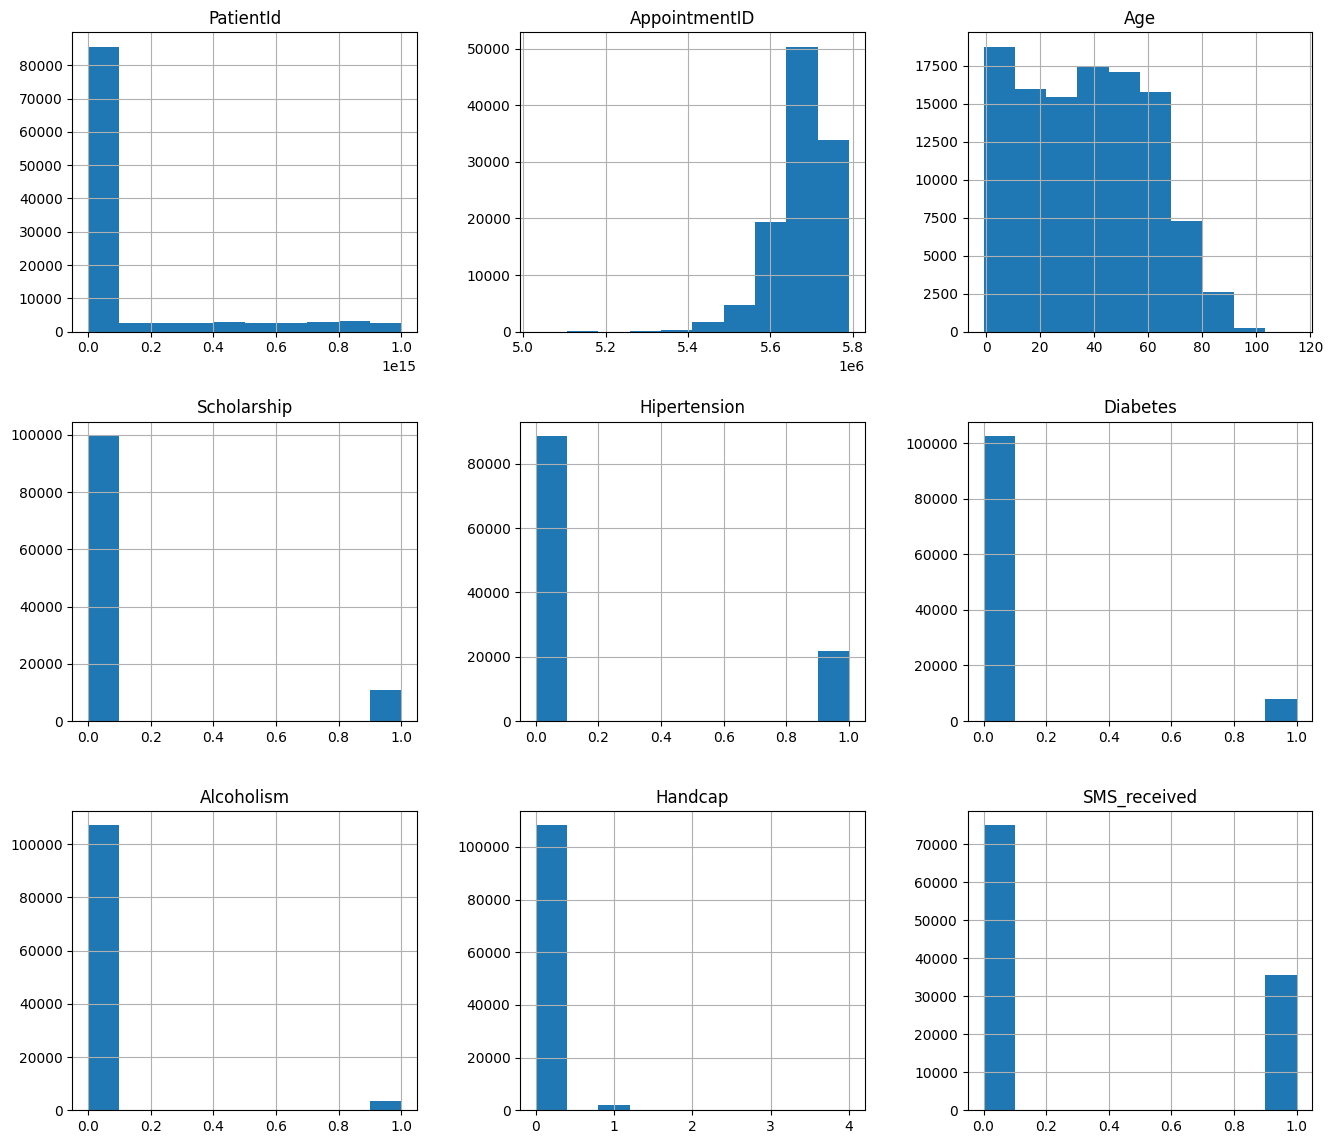

In [96]:
df.hist(figsize=(16,14));
#логируем гистограмму
experiment.log_figure(figure=plt)

*Проанализируем число людей каждого возраста*

In [97]:
print("Уникальные значения в `Age` => {}".format(df.Age.unique()))

Уникальные значения в `Age` => [ 62  56   8  76  23  39  21  19  30  29  22  28  54  15  50  40  46   4
  13  65  45  51  32  12  61  38  79  18  63  64  85  59  55  71  49  78
  31  58  27   6   2  11   7   0   3   1  69  68  60  67  36  10  35  20
  26  34  33  16  42   5  47  17  41  44  37  24  66  77  81  70  53  75
  73  52  74  43  89  57  14   9  48  83  72  25  80  87  88  84  82  90
  94  86  91  98  92  96  93  95  97 102 115 100  99  -1]


In [98]:
# Удалим аномальные значения
df = df[(df.Age >= 0) & (df.Age <= 110)]
df.Age.value_counts()

Age
0      3539
1      2273
52     1746
49     1652
53     1651
       ... 
97       11
98        6
100       4
102       2
99        1
Name: count, Length: 102, dtype: int64

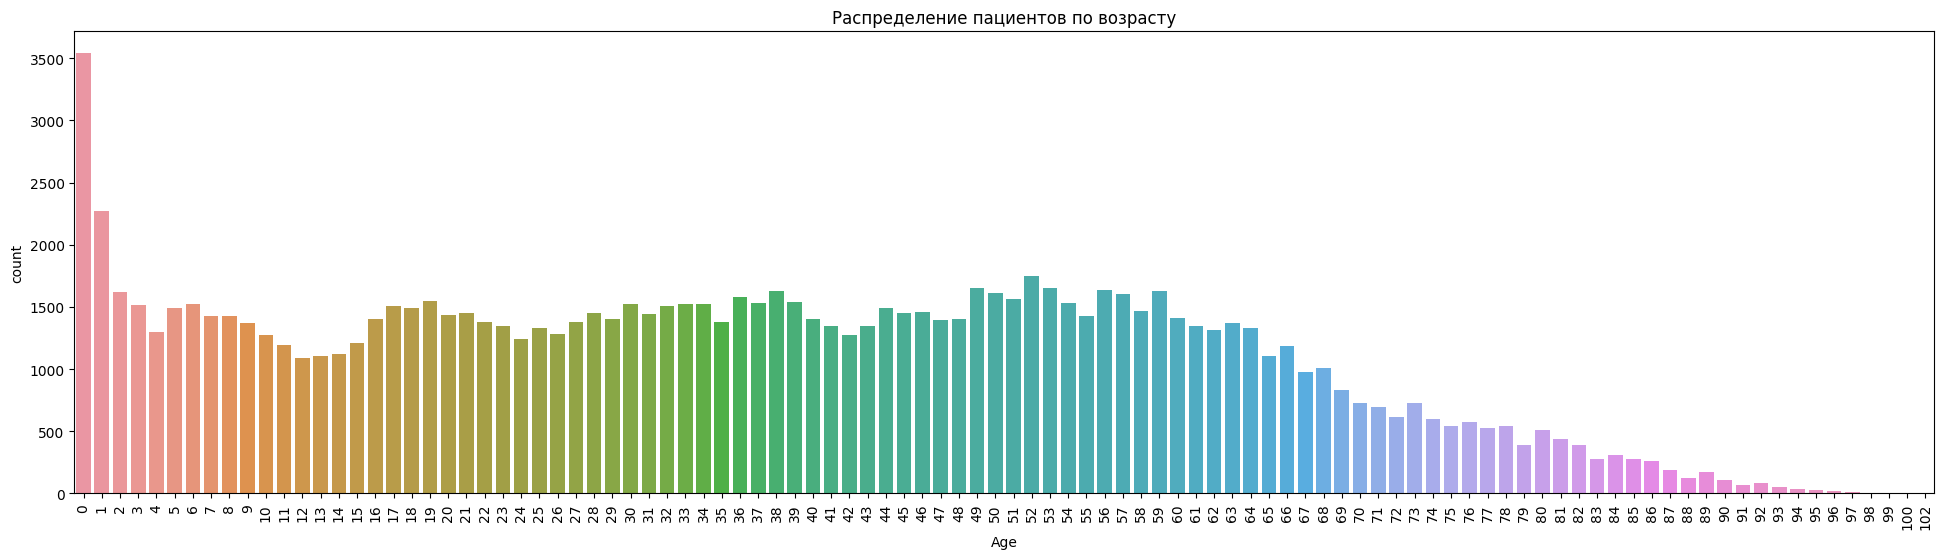

In [99]:
plt.figure(figsize=(24,6))
plt.xticks(rotation=90)
ax = sns.countplot(x=df.Age)
ax.set_title("Распределение пациентов по возрасту")
experiment.log_figure(figure=plt)
plt.show()

# Придет ли пациент на назначенный прием? 

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110521 non-null  float64
 1   AppointmentID   110521 non-null  int64  
 2   Gender          110521 non-null  object 
 3   ScheduledDay    110521 non-null  object 
 4   AppointmentDay  110521 non-null  object 
 5   Age             110521 non-null  int64  
 6   Neighbourhood   110521 non-null  object 
 7   Scholarship     110521 non-null  int64  
 8   Hipertension    110521 non-null  int64  
 9   Diabetes        110521 non-null  int64  
 10  Alcoholism      110521 non-null  int64  
 11  Handcap         110521 non-null  int64  
 12  SMS_received    110521 non-null  int64  
 13  No-show         110521 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 12.6+ MB


## Кодировка категориальных признаков

In [101]:
categorical_columns_names = ['Gender', 'Neighbourhood']

In [102]:
encoded_columns = pd.get_dummies(df, columns = categorical_columns_names)

In [103]:
encoded_columns.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show'], axis=1, inplace = True)

In [104]:
encoded_columns.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Gender_F,Gender_M,Neighbourhood_AEROPORTO,...,Neighbourhood_SANTOS REIS,Neighbourhood_SEGURANÇA DO LAR,Neighbourhood_SOLON BORGES,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM
0,62,0,1,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,56,0,0,0,0,0,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,62,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,8,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,0,1,1,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [105]:
y = df['No-show']

In [106]:
y

0         No
1         No
2         No
3         No
4         No
          ..
110522    No
110523    No
110524    No
110525    No
110526    No
Name: No-show, Length: 110521, dtype: object

In [107]:
y = y.replace({'No': 0, 'Yes': 1})

In [108]:
y.value_counts(True)

No-show
0    0.798084
1    0.201916
Name: proportion, dtype: float64

## Шкалирование данных

In [109]:
from sklearn.preprocessing import MinMaxScaler

In [110]:
scaler = MinMaxScaler()
X = scaler.fit_transform(encoded_columns)

In [111]:
print(X.shape)

(110521, 90)


# Модель (этот раздел будет подробно изучен далее в курсе)

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Инициализация модели

In [113]:
logreg = LogisticRegression()

In [114]:
random_state = 42

### Обучение модели

In [115]:
logreg.fit(X, y)

c:\Users\Temnykov\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### Логирование параметров обучения

In [116]:
params={"random_state":random_state,
        "model_type":"logreg"
}

In [117]:
experiment.log_parameters(params)

### Предсказания модели

In [118]:
y_pred = logreg.predict(X)

### Анализ модели

In [119]:
accuracy = accuracy_score(y, y_pred)

print("Доля правильных ответов: {:6.3f}".format(accuracy))

Доля правильных ответов:  0.798


# Логирование метрик

In [120]:
metrics = {"accuracy":accuracy}

In [121]:
experiment.log_metrics(metrics)

<img src='https://lms.skillfactory.ru/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block@r2yYhe2DpE4d3WKP.png' width=700px>

In [122]:
experiment.log_confusion_matrix(y.tolist(), y_pred.tolist())

{'web': 'https://www.comet.com/api/asset/download?assetId=4c0d8e884c55482da88213f7f3395b85&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=4c0d8e884c55482da88213f7f3395b85&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'assetId': '4c0d8e884c55482da88213f7f3395b85'}

In [123]:
experiment.display()

# Домашнее задание

Визуализируйте корреляцию между числовыми признаками, использованными для обучения модели и залогируйте изображение в Comet.

В качестве ответа приложите обновленный ноутбук.

*Форма оценки ментором:*

1) Проведена визуализация корреляции между 7 числовыми признаками, использованными для обучения модели - 5 баллов

2) Произведено логирование графика в CometMl - 10 баллов



In [124]:
# Отсеиваем лишние признаки чтоб привести к виду "encoded_columns",
# оставив признаки 'Gender', 'Neighbourhood' без кодирования их отсеет функция corr(numeric_only=True)
numeric_data=df.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show'], axis=1)#, inplace = True)
numeric_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Gender         110521 non-null  object
 1   Age            110521 non-null  int64 
 2   Neighbourhood  110521 non-null  object
 3   Scholarship    110521 non-null  int64 
 4   Hipertension   110521 non-null  int64 
 5   Diabetes       110521 non-null  int64 
 6   Alcoholism     110521 non-null  int64 
 7   Handcap        110521 non-null  int64 
 8   SMS_received   110521 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 8.4+ MB


Получено 7 числовых признака можно создать табличу и загрузить в Comet

{'web': 'https://www.comet.com/api/image/download?imageId=a6e0b25e89774e6aa459473b70bae933&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=a6e0b25e89774e6aa459473b70bae933&experimentKey=99aa4654d17948ffae6ea58143bf4a7b',
 'imageId': 'a6e0b25e89774e6aa459473b70bae933'}

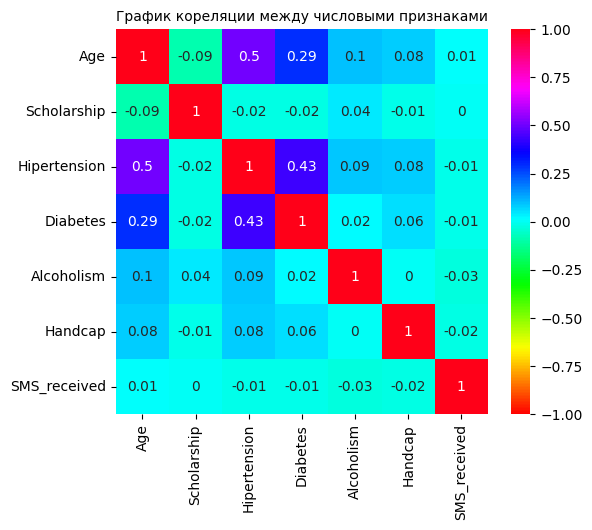

In [125]:
# кореляция только числовых признаков
temp=numeric_data.corr(numeric_only=True).round(2)              # создаем таблицу корреляции
# зазмер полотна
plt.figure(figsize=(6,5))
# График тепловая карта
ax = sns.heatmap(temp,                       # df
            annot=True,                 # вывод надписей (подписать фон)
            vmin=-1, vmax=1, center= 0, # границы
            тепловой шкалы
            cmap= 'hsv',                # палитра цветов  https://matplotlib.org/2.0.2/examples/color/colormaps_reference.html
            ).set_title('График корреляции между числовыми признаками', fontsize=10);
# логирование графика в CometMl
experiment.log_figure(figure=plt)
# plt.show()

Выход из CometML

In [126]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/glorit/medical-appointment/99aa4654d17948ffae6ea58143bf4a7b
COMET INFO:   Metrics:
COMET INFO:     accuracy : 0.7980836221170637
COMET INFO:   Parameters:
COMET INFO:     C                 : 1.0
COMET INFO:     class_weight      : None
COMET INFO:     clip              : False
COMET INFO:     copy              : True
COMET INFO:     dual              : False
COMET INFO:     feature_range     : (0, 1)
COMET INFO:     fit_intercept     : True
COMET INFO:     intercept_scaling : 1
COMET INFO:     l1_ratio          : None
COMET INFO:     max_iter          : 100
COMET INFO:     model_type        : logreg
COMET INFO:     multi_class  

### Итоги
* Научились
    1. Прятать логин, пароль и API ключ
    2. Загружать Logi и графики в Comet